# In this task we are going to do cancer prediction model

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import ElasticNet,Lasso,Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from scipy import stats
from sklearn.feature_selection import f_regression
from sklearn.datasets import load_breast_cancer
from collections import Counter



data = pd.read_csv('../../Datasets/fromclass/cancerData.csv')
cancer = load_breast_cancer()
data.drop(['id','Unnamed: 32'],axis=1, inplace=True)



In [89]:
data['diagnosis'] = [1 if value == 'M' else 0 for value in data.diagnosis]
data['diagnosis'] = data['diagnosis'].astype('category', copy=False)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        90
           1       0.98      0.96      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



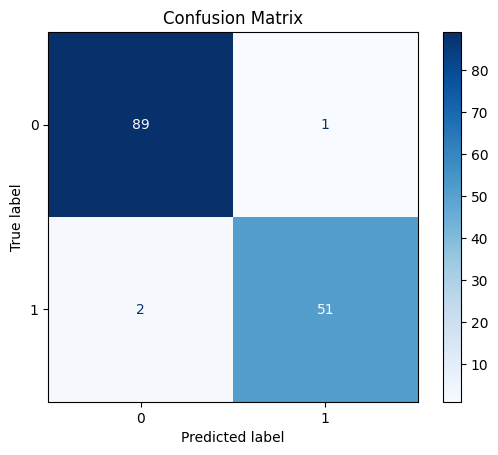

Acctual: Counter({np.int64(0): 91, np.int64(1): 52}), 
Test: Counter({0: 90, 1: 53})


In [90]:

y = data['diagnosis']
X = data.drop(['diagnosis'], axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)


lr = LogisticRegression(max_iter=5000)

threshold = 0.3

lr.fit(x_train, y_train)

probs = lr.predict_proba(x_test)[:, 1]  



y_pred_custom = (probs >= threshold).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))
# print("\nFirst 10 probabilities:", probs[:10])
# print()
# print("First 10 predictions:", y_pred_custom[:10])



cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()



print(f'Acctual: {Counter(y_pred_custom)}, ')
print(f'Test: {Counter(y_test)}')

